# Loan Default Prediction & Credit Risk Modelling

A comparative machine-learning study of **Logistic Regression, Random Forest, Gradient Boosting, LightGBM, and an Artificial Neural Network** for binary loan-default prediction.

### Project overview
- **148,670** loan applications and **34** original variables
- Binary target: `Status` (`1 = Default`, `0 = Non-default`)
- Approximately **24.6%** default cases
- Six predictors retained through the original correlation-based feature-selection process
- Five supervised-learning models evaluated on the same 70/30 hold-out split

This notebook is a portfolio-ready reproduction of the modelling workflow used in the original study. The analytical logic and reported results are intentionally preserved.

> **Methodology note:** The original workflow performs feature selection and standardisation before the train/test split and retains thresholds from the original F1-optimisation stage. These choices are documented here for reproducibility. A production implementation would use train-only preprocessing and validation-based threshold selection.

## 1. Setup and data loading

Place `Loan_Default.csv` beside the notebook, in a `data/` folder, or upload it when prompted in Google Colab.

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    roc_curve,
)

from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [ ]:
candidate_paths = [
    Path("Loan_Default.csv"),
    Path("data/Loan_Default.csv"),
    Path("/content/Loan_Default.csv"),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        print("Loan_Default.csv was not found. Please upload the dataset.")
        uploaded = files.upload()
        DATA_PATH = Path(next(iter(uploaded)))
    except Exception as exc:
        raise FileNotFoundError(
            "Place Loan_Default.csv beside this notebook or inside a data/ folder."
        ) from exc

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Default rate: {df['Status'].mean():.2%}")
df.head()

## 2. Exploratory data analysis

The portfolio version keeps the charts that support the modelling decisions rather than every exploratory plot produced during development.

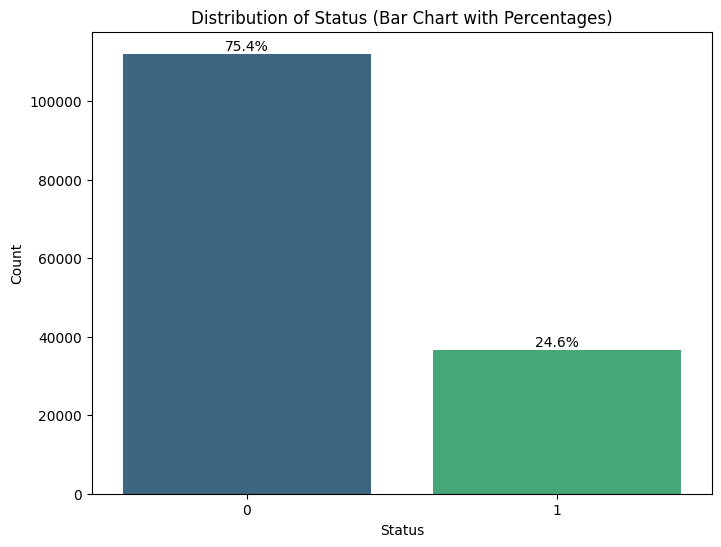

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="Status")
plt.title("Loan Default Class Distribution")
plt.xlabel("Status (0 = Non-default, 1 = Default)")
plt.ylabel("Applications")

total = len(df)
for p in ax.patches:
    ax.annotate(
        f"{100 * p.get_height() / total:.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

### Categorical predictors

The original study retained four categorical variables that showed meaningful differences in default behaviour.

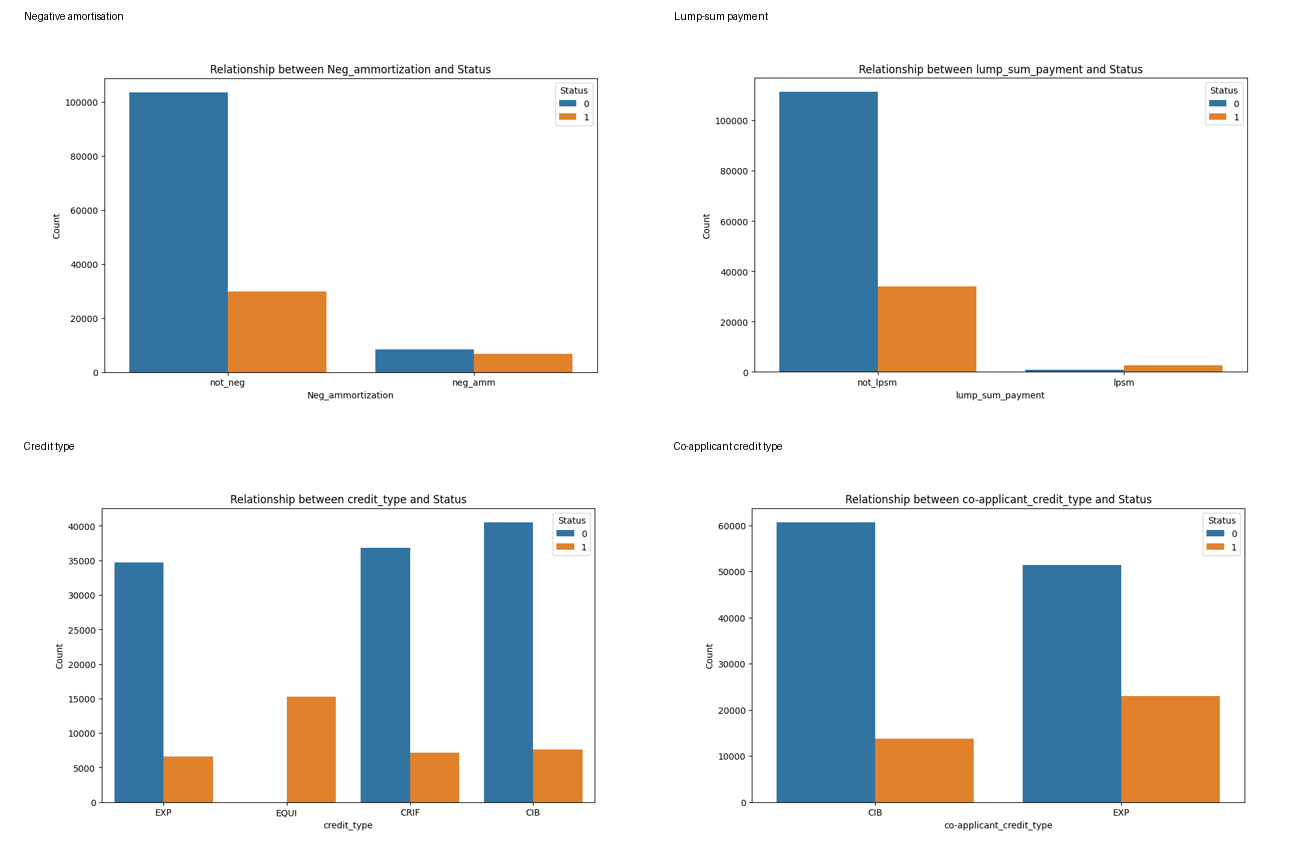

In [ ]:
categorical_features = [
    "Neg_ammortization",
    "lump_sum_payment",
    "credit_type",
    "co-applicant_credit_type",
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for feature, ax in zip(categorical_features, axes.ravel()):
    sns.countplot(data=df, x=feature, hue="Status", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Numerical predictors

`Upfront_charges` and `property_value` are strongly right-skewed. The original study retained the high-value observations because they represent plausible financial cases rather than obvious data-entry errors.

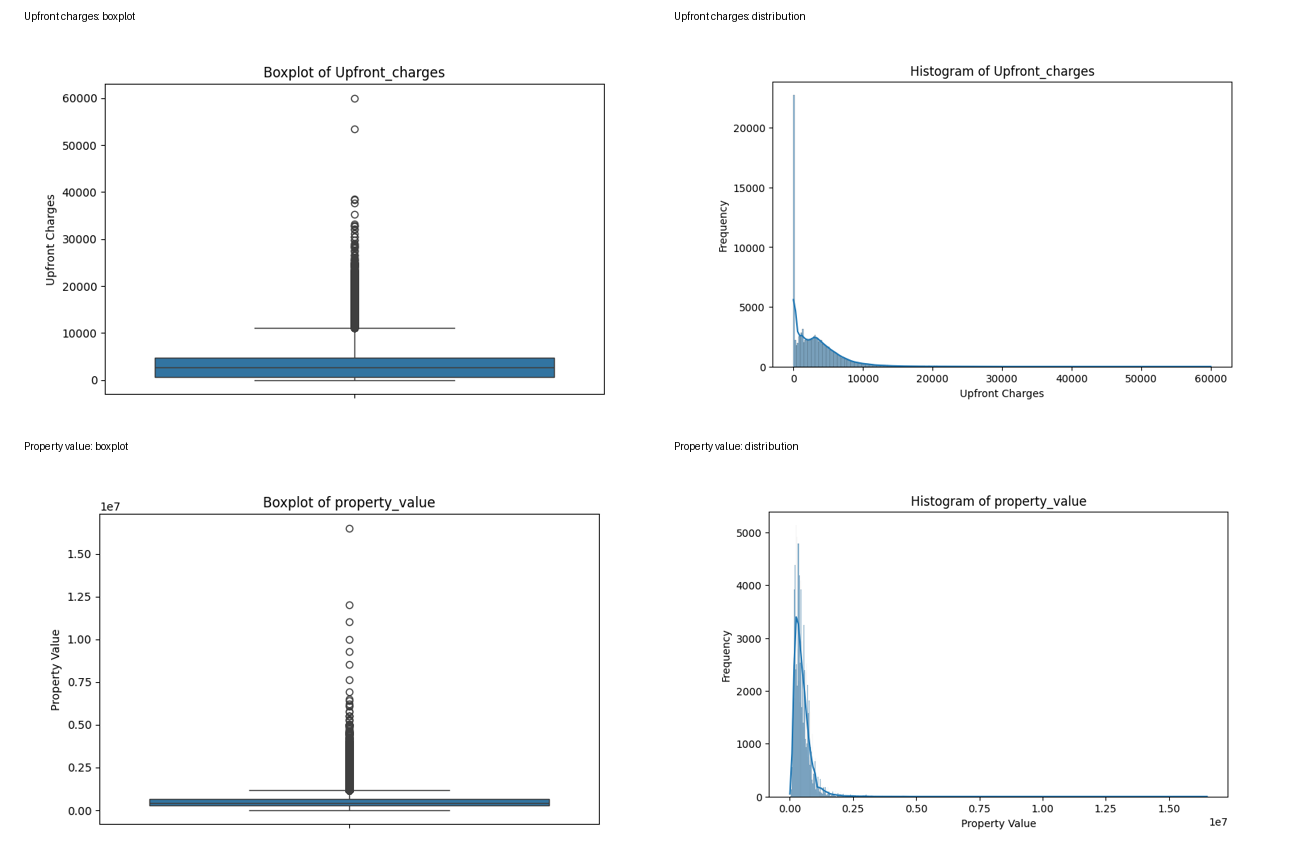

In [ ]:
numerical_features = ["Upfront_charges", "property_value"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.boxplot(y=df["Upfront_charges"], ax=axes[0, 0])
axes[0, 0].set_title("Upfront Charges - Boxplot")

sns.histplot(df["Upfront_charges"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Upfront Charges - Distribution")

sns.boxplot(y=df["property_value"], ax=axes[1, 0])
axes[1, 0].set_title("Property Value - Boxplot")

sns.histplot(df["property_value"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Property Value - Distribution")

plt.tight_layout()
plt.show()

## 3. Data preparation

The following steps reproduce the preprocessing used in the original study:

- remove exact duplicate rows;
- mode-impute variables with substantial missingness;
- remove remaining rows with missing values in selected fields;
- label-encode categorical variables;
- remove `ID` and `year`;
- retain the six final predictors.

In [ ]:
df = df.drop_duplicates().copy()

mode_impute_columns = [
    "loan_limit",
    "rate_of_interest",
    "Interest_rate_spread",
    "Upfront_charges",
    "property_value",
    "LTV",
    "dtir1",
    "income",
]

for column in mode_impute_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

drop_missing_columns = [
    "approv_in_adv",
    "loan_purpose",
    "term",
    "Neg_ammortization",
    "age",
    "submission_of_application",
]

df = df.dropna(subset=drop_missing_columns).copy()

print(f"Rows after cleaning: {len(df):,}")
print(f"Default rate after cleaning: {df['Status'].mean():.2%}")

In [ ]:
categorical_columns = [
    "loan_limit", "Gender", "approv_in_adv", "loan_type", "loan_purpose",
    "Credit_Worthiness", "open_credit", "business_or_commercial",
    "Neg_ammortization", "interest_only", "lump_sum_payment",
    "construction_type", "occupancy_type", "Secured_by", "total_units",
    "credit_type", "co-applicant_credit_type", "age",
    "submission_of_application", "Region", "Security_Type",
]

label_encoder = preprocessing.LabelEncoder()

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

df = df.drop(columns=["ID", "year"])

### Final modelling variables

The final predictors were:

1. `Upfront_charges`
2. `Neg_ammortization`
3. `lump_sum_payment`
4. `property_value`
5. `credit_type`
6. `co-applicant_credit_type`

A compact correlation matrix is shown below instead of the full 30+ variable heatmap used during initial exploration.

In [ ]:
selected_features = [
    "Upfront_charges",
    "Neg_ammortization",
    "lump_sum_payment",
    "property_value",
    "credit_type",
    "co-applicant_credit_type",
]

corr_view = df[selected_features + ["Status"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_view, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Final Modelling Variables")
plt.tight_layout()
plt.show()

## 4. Original train/test workflow

The feature matrix is standardised and then split into **70% training / 30% testing** using `random_state=42`, matching the original study.

In [ ]:
Y = df["Status"]
X = df[selected_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled,
    Y,
    test_size=0.30,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {len(x_train):,}")
print(f"Testing rows : {len(x_test):,}")
print(f"Features     : {len(selected_features)}")

## 5. Model development

Each model uses the same feature set and test split. The probability thresholds shown below are the values retained from the original F1-optimisation stage.

### 5.1 Logistic Regression

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver="liblinear",
    class_weight="balanced",
)
logistic_model.fit(x_train, y_train)

lr_prob = logistic_model.predict_proba(x_test)[:, 1]
lr_threshold = 0.75
lr_pred = (lr_prob >= lr_threshold).astype(int)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)
lr_f1 = f1_score(y_test, lr_pred)

print(f"Threshold : {lr_threshold:.4f}")
print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"ROC-AUC   : {lr_auc:.4f}")
print(f"F1-score  : {lr_f1:.4f}")
print(classification_report(y_test, lr_pred))

Logistic Regression
Threshold : 0.7500
Accuracy  : 0.8779
ROC-AUC   : 0.9487
F1-score  : 0.7729

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     33312
           1       0.71      0.84      0.77     10871

    accuracy                           0.88     44183
   macro avg       0.83      0.87      0.84     44183
weighted avg       0.89      0.88      0.88     44183

Confusion Matrix:
[[29614  3698]
 [ 1695  9176]]


### 5.2 Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(x_train, y_train)

rf_prob = rf_model.predict_proba(x_test)[:, 1]
rf_threshold = 0.6313
rf_pred = (rf_prob >= rf_threshold).astype(int)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Threshold : {rf_threshold:.4f}")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")
print(f"F1-score  : {rf_f1:.4f}")
print(classification_report(y_test, rf_pred))

Random Forest
Threshold : 0.6313
Accuracy  : 0.8908
ROC-AUC   : 0.9630
F1-score  : 0.7929

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93     33312
           1       0.74      0.85      0.79     10871

    accuracy                           0.89     44183
   macro avg       0.85      0.88      0.86     44183
weighted avg       0.90      0.89      0.89     44183

Confusion Matrix:
[[30122  3190]
 [ 1635  9236]]


### 5.3 Gradient Boosting

In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    random_state=RANDOM_STATE,
)

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
gb_model.fit(x_train, y_train, sample_weight=sample_weights)

gb_prob = gb_model.predict_proba(x_test)[:, 1]
gb_threshold = 0.6896
gb_pred = (gb_prob >= gb_threshold).astype(int)

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_auc = roc_auc_score(y_test, gb_prob)
gb_f1 = f1_score(y_test, gb_pred)

print(f"Threshold : {gb_threshold:.4f}")
print(f"Accuracy  : {gb_accuracy:.4f}")
print(f"ROC-AUC   : {gb_auc:.4f}")
print(f"F1-score  : {gb_f1:.4f}")
print(classification_report(y_test, gb_pred))

Gradient Boosting
Threshold : 0.6896
Accuracy  : 0.8997
ROC-AUC   : 0.9666
F1-score  : 0.8022

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     33312
           1       0.78      0.83      0.80     10871

    accuracy                           0.90     44183
   macro avg       0.86      0.88      0.87     44183
weighted avg       0.90      0.90      0.90     44183

Confusion Matrix:
[[30764  2548]
 [ 1884  8987]]


### 5.4 LightGBM

In [ ]:
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    boosting_type="gbdt",
    verbosity=-1,
)
lgb_model.fit(x_train, y_train)

lgb_prob = lgb_model.predict_proba(x_test)[:, 1]
lgb_threshold = 0.6831
lgb_pred = (lgb_prob >= lgb_threshold).astype(int)

lgb_accuracy = accuracy_score(y_test, lgb_pred)
lgb_auc = roc_auc_score(y_test, lgb_prob)
lgb_f1 = f1_score(y_test, lgb_pred)

print(f"Threshold : {lgb_threshold:.4f}")
print(f"Accuracy  : {lgb_accuracy:.4f}")
print(f"ROC-AUC   : {lgb_auc:.4f}")
print(f"F1-score  : {lgb_f1:.4f}")
print(classification_report(y_test, lgb_pred))

LightGBM
Threshold : 0.6831
Accuracy  : 0.9001
ROC-AUC   : 0.9672
F1-score  : 0.8030

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     33312
           1       0.78      0.83      0.80     10871

    accuracy                           0.90     44183
   macro avg       0.86      0.88      0.87     44183
weighted avg       0.90      0.90      0.90     44183

Confusion Matrix:
[[30780  2532]
 [ 1880  8991]]


### 5.5 Artificial Neural Network

The original ANN uses a six-layer MLP with dropout regularisation, Adam optimisation, and early stopping. Small numerical variation is expected across reruns because neural-network training is stochastic.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

ann_model = Sequential([
    Dense(256, activation="relu", input_shape=(x_train.shape[1],)),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(64, activation="relu"),
    Dropout(0.1),
    Dense(32, activation="relu"),
    Dropout(0.1),
    Dense(16, activation="relu"),
    Dropout(0.1),
    Dense(8, activation="relu"),
    Dropout(0.1),
    Dense(1, activation="sigmoid"),
])

ann_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=0,
)

history = ann_model.fit(
    x_train,
    y_train,
    validation_split=0.20,
    epochs=150,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=0,
)

ann_prob = ann_model.predict(x_test, verbose=0).ravel()
ann_threshold = 0.40
ann_pred = (ann_prob >= ann_threshold).astype(int)

ann_accuracy = accuracy_score(y_test, ann_pred)
ann_auc = roc_auc_score(y_test, ann_prob)
ann_f1 = f1_score(y_test, ann_pred)

print(f"Threshold : {ann_threshold:.4f}")
print(f"Accuracy  : {ann_accuracy:.4f}")
print(f"ROC-AUC   : {ann_auc:.4f}")
print(f"F1-score  : {ann_f1:.4f}")
print(classification_report(y_test, ann_pred))

Artificial Neural Network
Threshold : 0.4000
Accuracy  : 0.8982
ROC-AUC   : 0.9662
F1-score  : 0.8002

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     33312
           1       0.77      0.83      0.80     10871

    accuracy                           0.90     44183
   macro avg       0.86      0.87      0.87     44183
weighted avg       0.90      0.90      0.90     44183

Confusion Matrix:
[[30674  2638]
 [ 1862  9009]]


## 6. Results and visual comparison

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "LightGBM",
        "ANN",
    ],
    "Threshold": [lr_threshold, rf_threshold, gb_threshold, lgb_threshold, ann_threshold],
    "Accuracy": [lr_accuracy, rf_accuracy, gb_accuracy, lgb_accuracy, ann_accuracy],
    "ROC_AUC": [lr_auc, rf_auc, gb_auc, lgb_auc, ann_auc],
    "F1": [lr_f1, rf_f1, gb_f1, lgb_f1, ann_f1],
})

results.sort_values("ROC_AUC", ascending=False)

### Reported model performance

| Model | Threshold | Accuracy | ROC-AUC | F1-score |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.7500 | 0.8779 | 0.9487 | 0.7729 |
| Random Forest | 0.6313 | 0.8908 | 0.9630 | 0.7929 |
| Gradient Boosting | 0.6896 | 0.8997 | 0.9666 | 0.8022 |
| **LightGBM** | **0.6831** | **0.9001** | **0.9672** | **0.8030** |
| ANN | 0.4000 | 0.8982 | 0.9662 | 0.8002 |

**LightGBM achieved the strongest overall result in the original comparative study.**

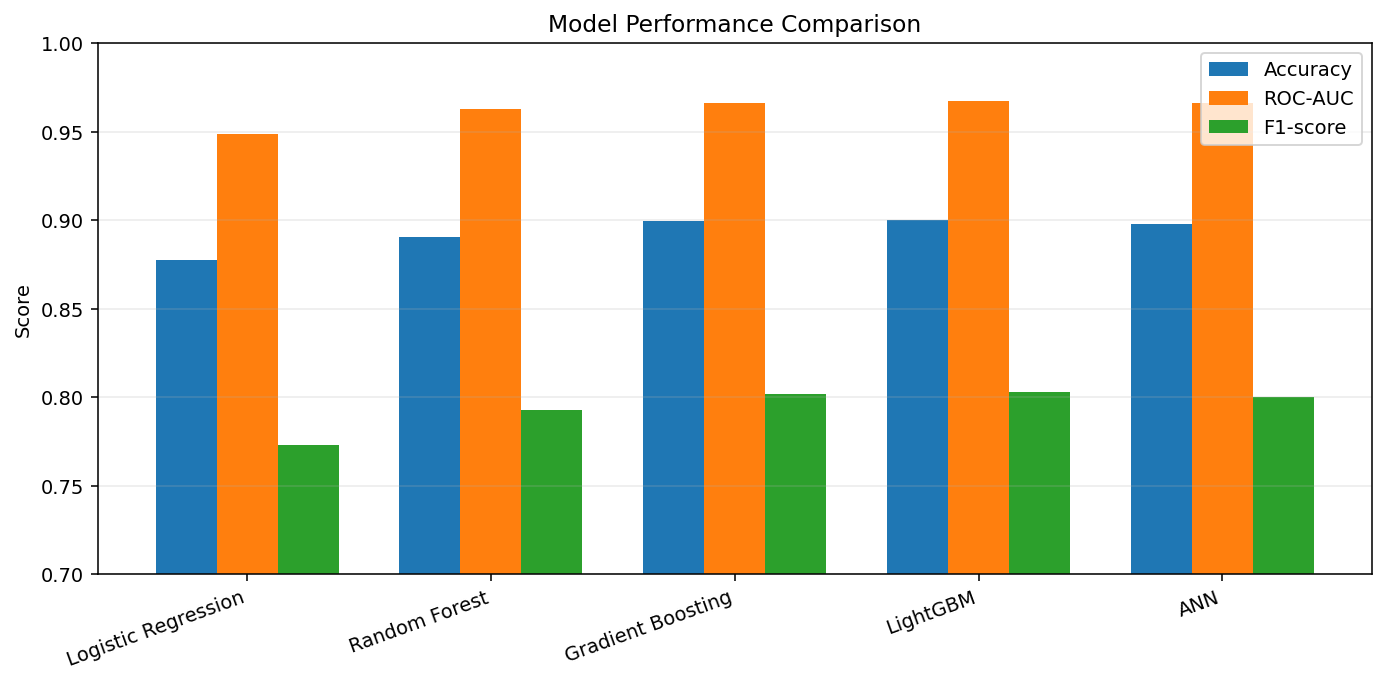

In [ ]:
metrics_plot = results.set_index("Model")[["Accuracy", "ROC_AUC", "F1"]]

ax = metrics_plot.plot(kind="bar", figsize=(11, 5))
ax.set_ylim(0.70, 1.00)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### ROC curves

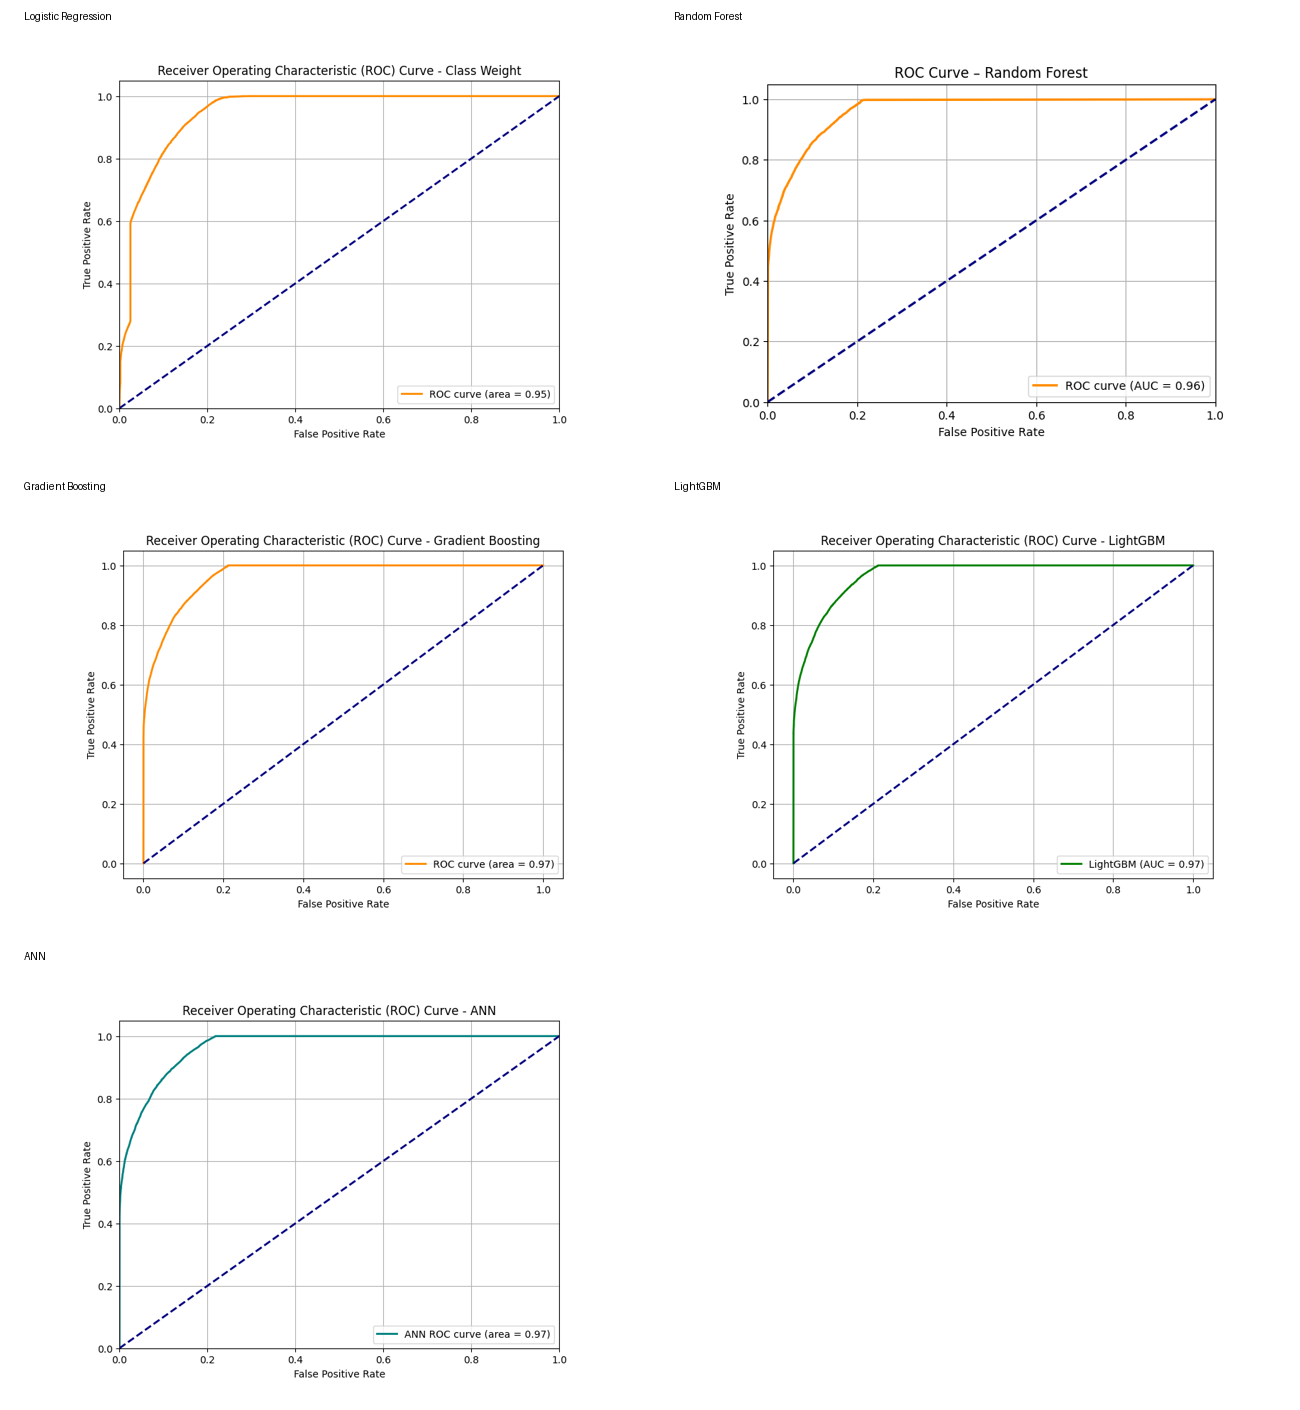

In [ ]:
model_probabilities = {
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
    "Gradient Boosting": gb_prob,
    "LightGBM": lgb_prob,
    "ANN": ann_prob,
}

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
for ax, (name, prob) in zip(axes.ravel(), model_probabilities.items()):
    fpr, tpr, _ = roc_curve(y_test, prob)
    model_auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f"AUC = {model_auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(alpha=0.25)

axes[-1, -1].axis("off")
fig.suptitle("ROC Curves by Model", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Confusion matrices

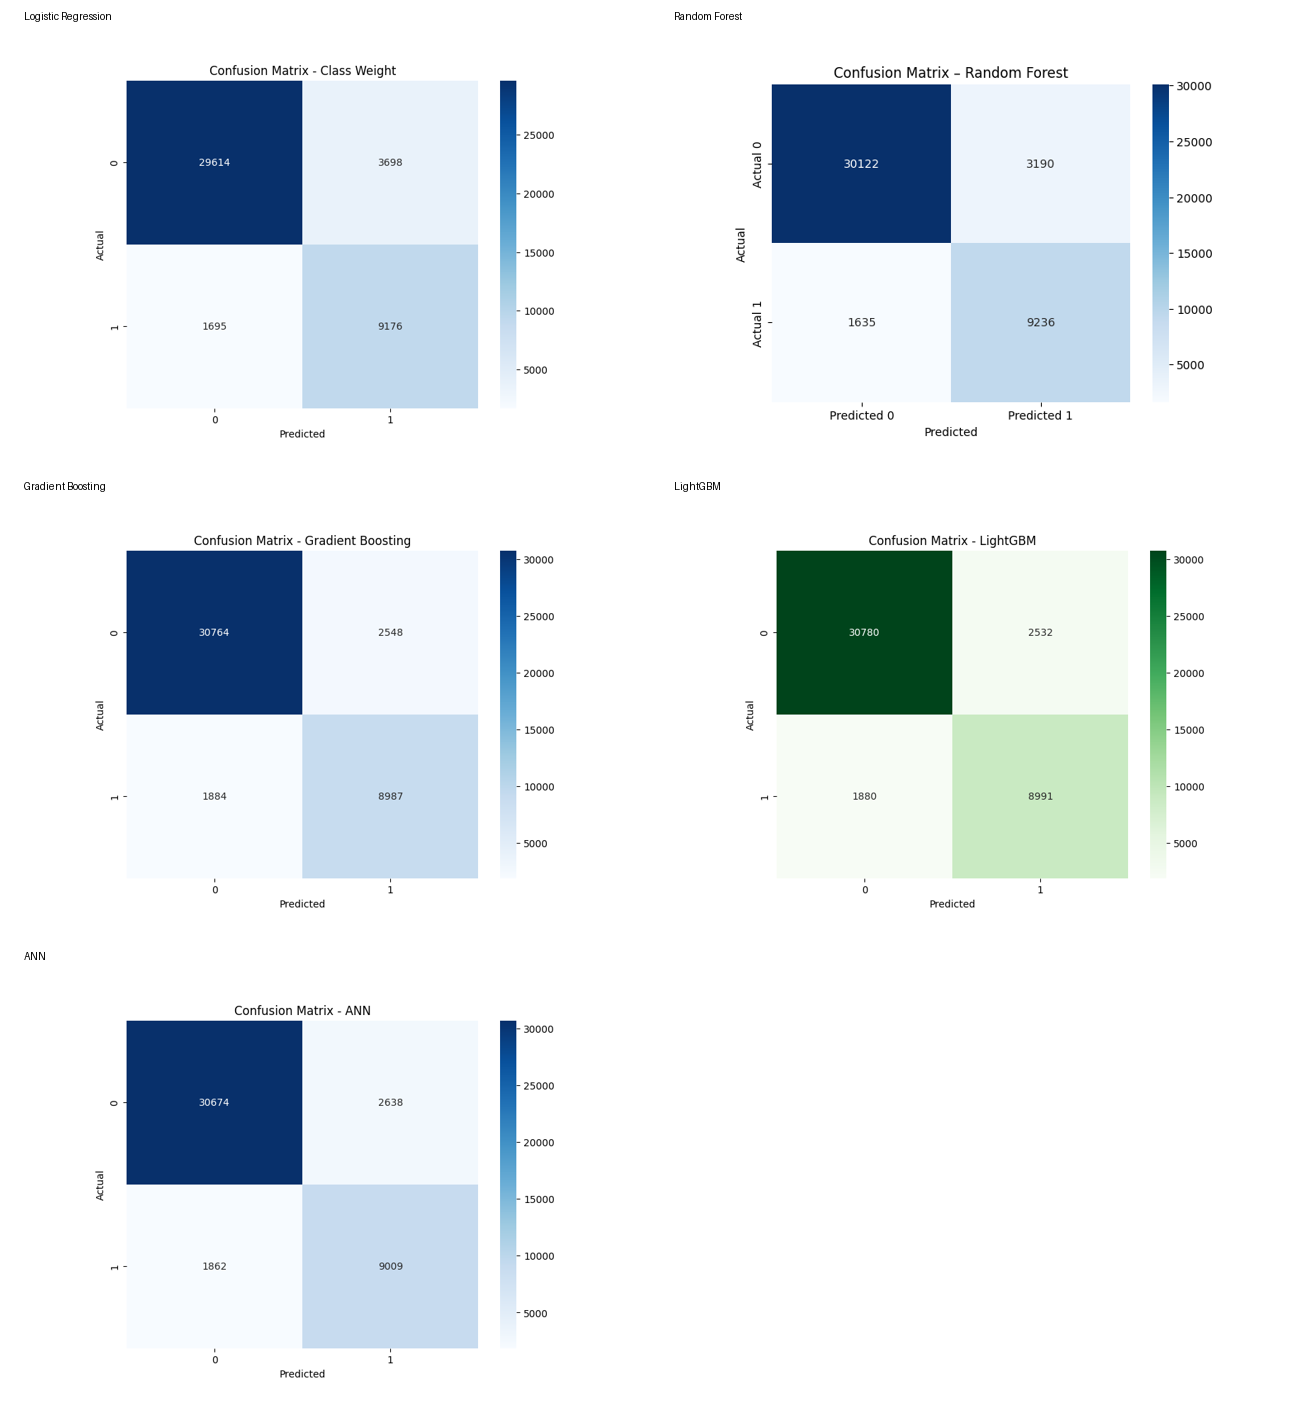

In [ ]:
model_predictions = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "LightGBM": lgb_pred,
    "ANN": ann_pred,
}

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
for ax, (name, pred) in zip(axes.ravel(), model_predictions.items()):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

axes[-1, -1].axis("off")
fig.suptitle("Confusion Matrices by Model", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Feature importance

The original study found that Logistic Regression, Random Forest, and Gradient Boosting placed substantial weight on `Upfront_charges`, while LightGBM emphasised `property_value`, `credit_type`, and `co-applicant_credit_type`.

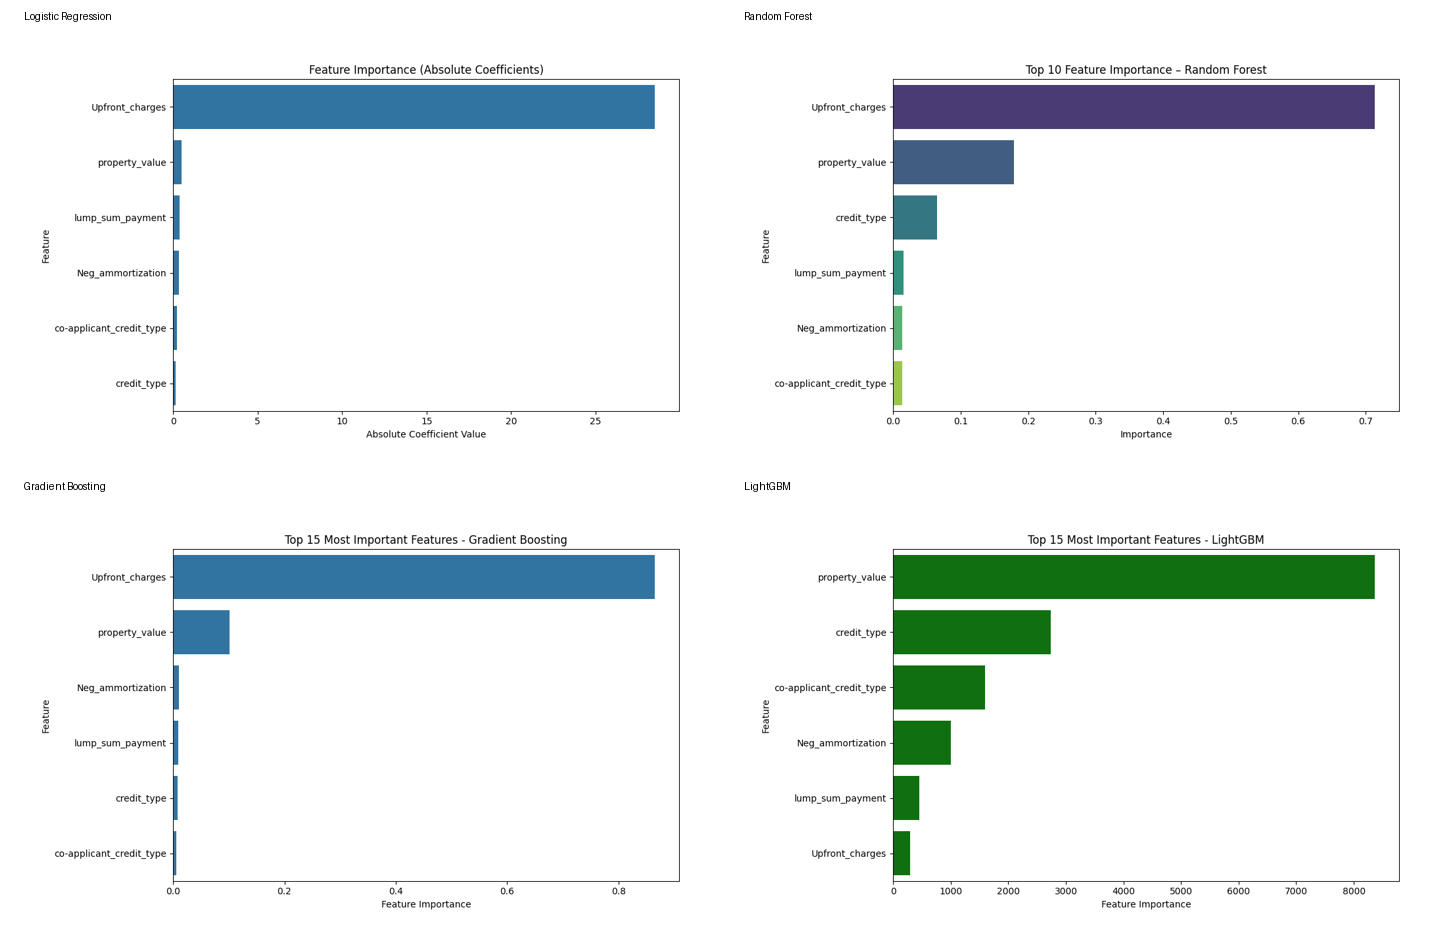

In [ ]:
lr_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": np.abs(logistic_model.coef_[0]),
}).sort_values("Importance", ascending=False)

rf_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": rf_model.feature_importances_,
}).sort_values("Importance", ascending=False)

gb_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": gb_model.feature_importances_,
}).sort_values("Importance", ascending=False)

lgb_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": lgb_model.feature_importances_,
}).sort_values("Importance", ascending=False)

importance_frames = {
    "Logistic Regression": lr_importance,
    "Random Forest": rf_importance,
    "Gradient Boosting": gb_importance,
    "LightGBM": lgb_importance,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, frame) in zip(axes.ravel(), importance_frames.items()):
    sns.barplot(data=frame, x="Importance", y="Feature", ax=ax)
    ax.set_title(name)
    ax.set_ylabel("")

fig.suptitle("Feature Importance Comparison", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### ANN training behaviour

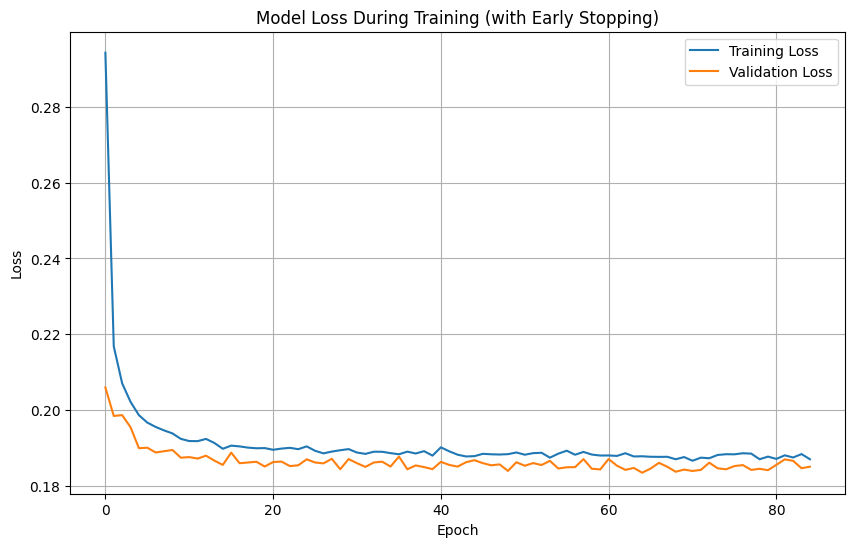

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("ANN Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 7. Interpretation and limitations

The ensemble methods outperform the linear baseline, with **LightGBM** producing the strongest overall result in the original study.

### Limitations
- The dataset is public rather than an institutional lending portfolio.
- The original workflow uses a single 70/30 hold-out split.
- Feature selection and standardisation were performed before the train/test split.
- The probability thresholds were retained from the original F1-optimisation procedure.
- ANN training can vary slightly between runs.

A stricter extension could use train-only preprocessing, a dedicated validation set, k-fold cross-validation, calibration, SHAP explanations, temporal backtesting, and explicit leakage auditing.